In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_landmarks     │ (None, 30, 104,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 30, 40, 3) │          0 │ input_landmarks[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 30, 21, 3) │          0 │ input_landmarks[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 30, 22, 3) │          0 │ input_landmarks[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 30, 21, 3) │          0 │ input_landmarks[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 30, 120)   │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 30, 63)    │          0 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 30, 66)    │          0 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 30, 63)    │          0 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lips_proj (Dense)   │ (None, 30, 128)   │     15,488 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_hand_proj      │ (None, 30, 128)   │      8,192 │ reshape_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upper_body_proj     │ (None, 30, 128)   │      8,576 │ reshape_2[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_hand_proj     │ (None, 30, 128)   │      8,192 │ reshape_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lips_ln             │ (None, 30, 128)   │        256 │ lips_proj[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ left_hand_ln        │ (None, 30, 128)   │        256 │ left_hand_proj[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upper_body_ln       │ (None, 30, 128)   │        256 │ upper_body_proj[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ right_hand_ln       │ (None, 30, 128)   │        256 │ right_hand_proj[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 128)   │          0 │ lips_ln[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 128)   │          0 │ left_hand_ln[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ upper_body_ln[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 30, 128)   │          0 │ right_hand_ln[0]

 Total params: 2,754,348 (10.51 MB)

 Trainable params: 2,754,348 (10.51 MB)

 Non-trainable params: 0 (0.00 B)

...

80/80 ━━━━━━━━━━━━━━━━━━━━ 60s 743ms/step - accuracy: 0.9848 - loss: 0.0854 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4851 - val_loss: 2.1977 - val_sparse_top_k_categorical_accuracy: 0.8085 - learning_rate: 6.3074e-05
Epoch 91/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.9886 - loss: 0.0699 - sparse_top_k_categorical_accuracy: 1.0000

80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 758ms/step - accuracy: 0.9886 - loss: 0.0699 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4867 - val_loss: 2.1914 - val_sparse_top_k_categorical_accuracy: 0.7975 - learning_rate: 6.2274e-05
Epoch 92/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 80s 733ms/step - accuracy: 0.9844 - loss: 0.0737 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4835 - val_loss: 2.1907 - val_sparse_top_k_categorical_accuracy: 0.8163 - learning_rate: 6.1471e-05
Epoch 93/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 730ms/step - accuracy: 0.9872 - loss: 0.0688 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4867 - val_loss: 2.2159 - val_sparse_top_k_categorical_accuracy: 0.8038 - learning_rate: 6.0665e-05
Epoch 94/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.9887 - loss: 0.0728 - sparse_top_k_categorical_accuracy: 1.0000

80/80 ━━━━━━━━━━━━━━━━━━━━ 83s 743ms/step - accuracy: 0.9887 - loss: 0.0728 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4882 - val_loss: 2.2076 - val_sparse_top_k_categorical_accuracy: 0.8038 - learning_rate: 5.9856e-05
Epoch 95/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 80s 716ms/step - accuracy: 0.9898 - loss: 0.0682 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4867 - val_loss: 2.2040 - val_sparse_top_k_categorical_accuracy: 0.8069 - learning_rate: 5.9044e-05
Epoch 96/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.9831 - loss: 0.0733 - sparse_top_k_categorical_accuracy: 1.0000

80/80 ━━━━━━━━━━━━━━━━━━━━ 86s 764ms/step - accuracy: 0.9832 - loss: 0.0732 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5086 - val_loss: 2.1777 - val_sparse_top_k_categorical_accuracy: 0.8116 - learning_rate: 5.8230e-05
Epoch 97/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 80s 738ms/step - accuracy: 0.9870 - loss: 0.0635 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4992 - val_loss: 2.1877 - val_sparse_top_k_categorical_accuracy: 0.8022 - learning_rate: 5.7413e-05
Epoch 98/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 739ms/step - accuracy: 0.9882 - loss: 0.0587 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4835 - val_loss: 2.1852 - val_sparse_top_k_categorical_accuracy: 0.8069 - learning_rate: 5.6595e-05
Epoch 99/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 87s 799ms/step - accuracy: 0.9888 - loss: 0.0625 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4914 - val_loss: 2.2231 - val_sparse_top_k_categorical_accuracy: 0.8022 - learning_rate: 5.5774e-05
Epoch 100

80/80 ━━━━━━━━━━━━━━━━━━━━ 81s 744ms/step - accuracy: 0.9930 - loss: 0.0380 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5196 - val_loss: 2.2080 - val_sparse_top_k_categorical_accuracy: 0.8085 - learning_rate: 4.2587e-05
Epoch 116/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 770ms/step - accuracy: 0.9865 - loss: 0.0429 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4945 - val_loss: 2.2057 - val_sparse_top_k_categorical_accuracy: 0.8022 - learning_rate: 4.1770e-05
Epoch 117/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 82s 768ms/step - accuracy: 0.9884 - loss: 0.0438 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.5039 - val_loss: 2.2251 - val_sparse_top_k_categorical_accuracy: 0.8116 - learning_rate: 4.0956e-05
Epoch 118/200
80/80 ━━━━━━━━━━━━━━━━━━━━ 87s 841ms/step - accuracy: 0.9880 - loss: 0.0396 - sparse_top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.4929 - val_loss: 2.2264 - val_sparse_top_k_categorical_accuracy: 0.7943 - learning_rate: 4.0144e-05
Epoch 

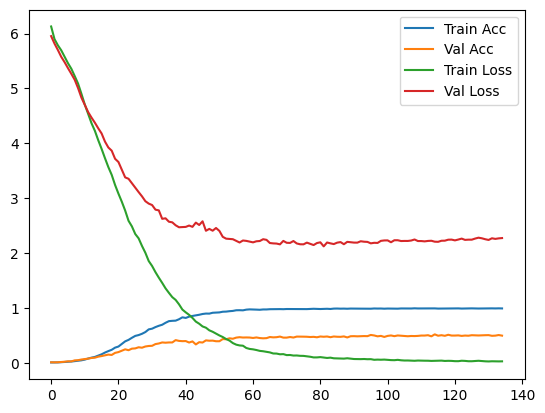

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Configuration
NUM_CLASSES = 300
FIXED_FRAMES = 30
FEATURE_DIM = 104
COORD_DIM = 3

# Model hyperparameters
UNITS = 256
NUM_HEADS = 8
NUM_TRANSFORMER_BLOCKS = 4
MLP_UNITS = 512
DROPOUT_RATE = 0.1

# Training hyperparameters
BATCH_SIZE = 32
EPOCHS = 200
INITIAL_LR = 1e-4
WEIGHT_DECAY = 1e-4

# Positional Encoding
def create_positional_encoding(seq_len, d_model):
    angles = np.arange(seq_len)[:, np.newaxis] / np.power(10000, (2 * (np.arange(d_model)[np.newaxis, :] // 2)) / d_model)
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(angles[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.constant(pos_encoding[np.newaxis], dtype=tf.float32)

# Transformer block
def transformer_block(x, num_heads, units, dropout):
    attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=units // num_heads, dropout=dropout)(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
    ffn = layers.Dense(units * 2, activation='gelu')(x)
    ffn = layers.Dropout(dropout)(ffn)
    ffn = layers.Dense(units)(ffn)
    return layers.LayerNormalization(epsilon=1e-6)(x + ffn)

# Slice helper
def slice_landmarks(start, length):
    return layers.Lambda(lambda x: x[:, :, start:start+length, :])

# Flatten body part
def process_body_part(x, name, output_dim):
    x = layers.Reshape((FIXED_FRAMES, -1))(x)
    x = layers.Dense(output_dim, activation='gelu', name=f'{name}_proj')(x)
    x = layers.LayerNormalization(name=f'{name}_ln')(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    return x

# Model builder
def create_model():
    inputs = layers.Input(shape=(FIXED_FRAMES, FEATURE_DIM, COORD_DIM), name='input_landmarks')

    lips = slice_landmarks(0, 40)(inputs)
    left_hand = slice_landmarks(40, 21)(inputs)
    upper_body = slice_landmarks(61, 22)(inputs)
    right_hand = slice_landmarks(83, 21)(inputs)

    lips = process_body_part(lips, 'lips', 128)
    left_hand = process_body_part(left_hand, 'left_hand', 128)
    upper_body = process_body_part(upper_body, 'upper_body', 128)
    right_hand = process_body_part(right_hand, 'right_hand', 128)

    x = layers.Concatenate()([lips, left_hand, upper_body, right_hand])
    x = layers.Dense(UNITS, activation='gelu', name='feature_proj')(x)
    x = layers.LayerNormalization()(x)

    pos_enc = create_positional_encoding(FIXED_FRAMES, UNITS)
    x = layers.Add()([x, pos_enc])
    x = layers.Dropout(DROPOUT_RATE)(x)

    for _ in range(NUM_TRANSFORMER_BLOCKS):
        x = transformer_block(x, NUM_HEADS, UNITS, DROPOUT_RATE)

    avg_pool = layers.GlobalAveragePooling1D()(x)
    max_pool = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    x = layers.Dense(512, activation='gelu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    x = layers.Dense(256, activation='gelu')(x)
    x = layers.LayerNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return models.Model(inputs, outputs)

# Cosine scheduler
def cosine_scheduler(lr, epochs, warmup=10):
    def scheduler(epoch):
        if epoch < warmup:
            return lr * (epoch + 1) / warmup
        progress = (epoch - warmup) / (epochs - warmup)
        return lr * 0.5 * (1 + np.cos(np.pi * progress))
    return scheduler

# Data preparation
def prepare_data():
    x = np.load("/content/feature_data.npy")
    y = np.load("/content/feature_labels.npy").astype(np.int32)
    return train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

# Training function
def train_model():
    train_x, val_x, train_y, val_y = prepare_data()
    model = create_model()
    model.summary()

    optimizer = optimizers.AdamW(learning_rate=INITIAL_LR, weight_decay=WEIGHT_DECAY)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5)]
    )

    cb = [
        callbacks.LearningRateScheduler(cosine_scheduler(INITIAL_LR, EPOCHS)),
        callbacks.EarlyStopping(patience=20, restore_best_weights=True, monitor='val_accuracy'),
        callbacks.ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy')
    ]

    history = model.fit(train_x, train_y, validation_data=(val_x, val_y),
                        epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=cb, verbose=1)

    val_loss, val_acc, val_top5 = model.evaluate(val_x, val_y)
    print(f"Val Acc: {val_acc:.4f} | Top-5 Acc: {val_top5:.4f}")
    return model, history

# Plotting
def plot_history(history):
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.legend()
    plt.show()

# Run training
if __name__ == "__main__":
    model, history = train_model()
    plot_history(history)


In [ ]:
from google.colab import files
files.download('best_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>